# Comparing the derivative of `sin(x)` with its central difference approximation

## Import libraries

In [1]:
import random
import autograd.numpy as np
import numpy as snp
import random
from autograd import grad
import matplotlib.pyplot as plt

In [2]:
rng = random.Random(42)

## Helper functions

In [3]:
def gen_random_n(low=1, high=10, decimals=3):
    """
    Generate a random float in [low, high), rounded to `decimals` places.
    The range and number of decimal places 
    can be adjusted to get a value easy to understand
    (i.e., instead of a very small float with many floating digits).
    
    """
    
    number = rng.uniform(low, high)
    number = round(number, decimals)

    print("Generated random number =", number)
    return number

In [4]:
def compute_sin_x(x):
    """Function to compute sin(x)"""
    return np.sin(x)

In [5]:
def central_difference(f, x, h):
    """Compute the central difference of func(x)."""
    
    forward_step = x + h
    backward_step = x - h
    
    approx_dev = (f(forward_step) - f(backward_step)) / (2*h)
    
    return approx_dev

In [6]:
def loop_central_difference(f, x, h_list):
    approx_derivatives = []
    
    for h in h_list:
        approx_dev = central_difference(f, x, h)
        approx_derivatives.append(approx_dev)

    return approx_derivatives

In [7]:
def validate_approx(approx_derivatives, derivative):
    results = []
    
    for i in approx_derivatives:
        close = np.allclose(i, derivative)
        results.append(close)
    
    print("allclose: ", results)
    return results

In [8]:
def plot_derivatives(derivative, approx_derivatives, h_values, x0, log_scale=True):
    """
    Plot the true derivative and the central difference approximation
    for various h values.

    Args:
        derivative (float): the true derivative at x0 (scalar).
        approx_derivatives (np.ndarray[float]): list of approximated derivatives for each h.
        h_values (list[float]): list of h values.
        x0 (float): the point x at which derivative is computed.
    
    """

    plt.figure(figsize=(10, 6))

    # Plot the approximations
    plt.plot(h_values, approx_derivatives, marker='o', linestyle='-', label='Central difference approximation')

    # Plot the actual derivative as a horizontal line
    plt.axhline(derivative, linestyle='--', color="red", label=f"True derivative = {derivative:.6f}")

    if log_scale:
        plt.xscale("log")

    # Axis labels & title
    plt.xlabel("h (step size)")
    plt.ylabel("Derivative value")

    plt.title(f"Derivative of sin(x) and central difference approximation at x = {x0}")

    # Ensure ticks for all h-values
    plt.xticks(h_values, rotation=90)
    all_y_ticks = list(approx_derivatives) # + [derivative] # They may overlap
    plt.yticks(all_y_ticks)

    # Optional grid
    plt.grid(True)

    plt.legend()
    plt.show()


## Experiment
### Generate `x` and compute the gradient of `sin(x)`

In [9]:
# Generate a small random float x and compute sin(x)
x = gen_random_n(low=1, high=10, decimals=3)
sin_x = compute_sin_x(x)
print("sin_x =", sin_x)

Generated random number = 6.755
sin_x = 0.45450346136058495


In [10]:
# Compute the gradient of sin(x) using `autograd`
dfdx = grad(compute_sin_x)
sin_x_prime = dfdx(x)
print("sin_x_prime =", sin_x_prime)

sin_x_prime = 0.8907449711400268


In [11]:
# Validate with ground truth (`sin_x_prime = cos(x)`)
cos_x = np.cos(x)
print("cos_x =", cos_x)
np.allclose(sin_x_prime, cos_x)

cos_x = 0.8907449711400268


True

### Approximate the gradient with the central difference method

In [12]:
# Stepsize values to experiment on
h_values = [0.0001, 0.001, 0.01, 0.1, 1, 10]

In [13]:
sin_x_prime_approx = loop_central_difference(compute_sin_x, x, h_values)
sin_x_prime_approx

[0.890744969653523,
 0.8907448226828374,
 0.8907301254647171,
 0.8892611382988893,
 0.7495360480778797,
 -0.04845840687187168]

## Plot results

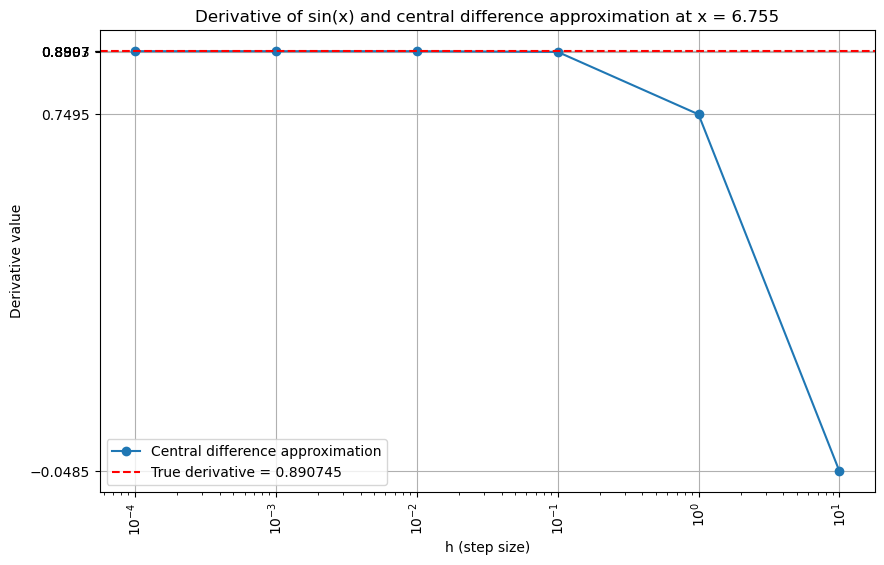

In [14]:
plot_derivatives(sin_x_prime, sin_x_prime_approx, h_values, x)

## Analysis & Conclusions

The plot shows that for fairly small values of stepsize `h`, the approximate derivative of `sin(x)` computed with central difference is very close to the actual derivative; although too small values of `h` would lead to numerical issues; the discrepancy would grow and the approximation would become 0 if `h` was too small (e,g., `1e-20`). Whereas, for stepsize `h >= 1`, the divergence between the approximation and actual derivative grows in an exponential-like manner.

In [17]:
# This can be validated numerically
print("h values:", h_values)
validation_list = validate_approx(sin_x_prime_approx, sin_x_prime)

h values: [0.0001, 0.001, 0.01, 0.1, 1, 10]
allclose:  [True, True, False, False, False, False]


Actually, when performing numerical validation, only the approximations with stepsize `h = [1e-4, 1e-3]` are consistently close enough to the real gradient, whereas `h = [1e-2, 1e-1]` are not consistently close enough, and `h = [1, 10]` are never close enough. This discrepancy between what the eye can see from the plot and what numerical validation returns highlights the importance of always numerically validating results when possible.